# Separation of the data
In this section, the original defungi dataset is divided into 80% training and 20% testing. The images are copied into a new folder structure while preserving the original class folders.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import random
import shutil

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
source_path = Path("/content/drive/MyDrive/TC3002/defungi")
separation_path = Path("/content/drive/MyDrive/TC3002/defungi_separation")

# % for training
training_percentage = 0.80

# Valid extensions
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

# Seed to reproduce the separation in future executions
random.seed(10)

In [4]:
#Create folders training and test
training_path = separation_path / "training"
test_path = separation_path / "test"

training_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)

In [5]:
#Function to get valid images
def get_image_files(folder_path):
    image_files = []

    for file in folder_path.iterdir():
        if file.suffix.lower() in image_extensions:
            image_files.append(file)

    return image_files


#Function to copy the images
def copy_images(image_list, destination_folder):
    destination_folder.mkdir(parents=True, exist_ok=True)

    for image_path in image_list:
        destination_path = destination_folder / image_path.name
        shutil.copy(image_path, destination_path)

for category_folder in source_path.iterdir():

    if not category_folder.is_dir():
        continue

    category_name = category_folder.name

    images = get_image_files(category_folder)
    random.shuffle(images)

    total_images = len(images)
    training_count = int(total_images * training_percentage)

    training_images = images[:training_count]
    test_images = images[training_count:]

    copy_images(training_images, training_path / category_name)
    copy_images(test_images, test_path / category_name)

    print(f"Category: {category_name}")
    print(f"Total of images: {total_images}")
    print(f"Training: {len(training_images)}")
    print(f"Test: {len(test_images)}")
    print("-" * 30)

print("Separation for training and test (80/20) ready.")

KeyboardInterrupt: 

# Preprocessing, scaling, and data augmentation
In this section, the separated dataset is loaded using Keras. The training set receives scaling and data augmentation, while the test set only receives scaling.

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import zipfile
import os

zip_path = "/content/defungi_separation-20260531T163540Z-3-001.zip"
extract_path = "/content/defungi_separation"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [10]:
img_height = 128
img_width = 128
batch_size = 32

training_path = "/content/defungi_separation/defungi_separation/training"
test_path = "/content/defungi_separation/defungi_separation/test"

## Note: Corrupted Image Cleaning Using AI

During the training process, an `UnidentifiedImageError` was raised, indicating that one or more corrupted image files were present in the dataset. This script was generated with the help of **AI** to identify and delete any corrupted or unreadable image files from both the training and test sets. After running the script, the corrupted images were removed and training was able to complete successfully.

In [36]:
from PIL import Image
import os

def validate_and_delete_corrupted_images(directory_path, image_extensions):
    print(f"Validating and cleaning images in: {directory_path}")
    corrupted_count = 0
    for root, _, files in os.walk(directory_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Verify that it is an image
                except (Image.UnidentifiedImageError, Exception) as e:
                    print(f"  🚨 Corrupted or invalid image found and deleted: {file_path} - {e}")
                    os.remove(file_path)
                    corrupted_count += 1
    if corrupted_count == 0:
        print(f"No corrupted images found in {directory_path}")
    else:
        print(f"Finished cleaning. {corrupted_count} corrupted images deleted from {directory_path}")
    print("\n")

valid_image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

# Clean training images
validate_and_delete_corrupted_images(training_path, valid_image_extensions)

# Clean test images (if needed, though previous check found none)
validate_and_delete_corrupted_images(test_path, valid_image_extensions)


Validating and cleaning images in: /content/defungi_separation/defungi_separation/training
No corrupted images found in /content/defungi_separation/defungi_separation/training


Validating and cleaning images in: /content/defungi_separation/defungi_separation/test
No corrupted images found in /content/defungi_separation/defungi_separation/test




In [12]:
training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [38]:
training_generator = training_datagen.flow_from_directory(
    training_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False

)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False

)

Found 7294 images belonging to 5 classes.
Found 1824 images belonging to 5 classes.


In [14]:
print(training_generator.class_indices)

{'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}


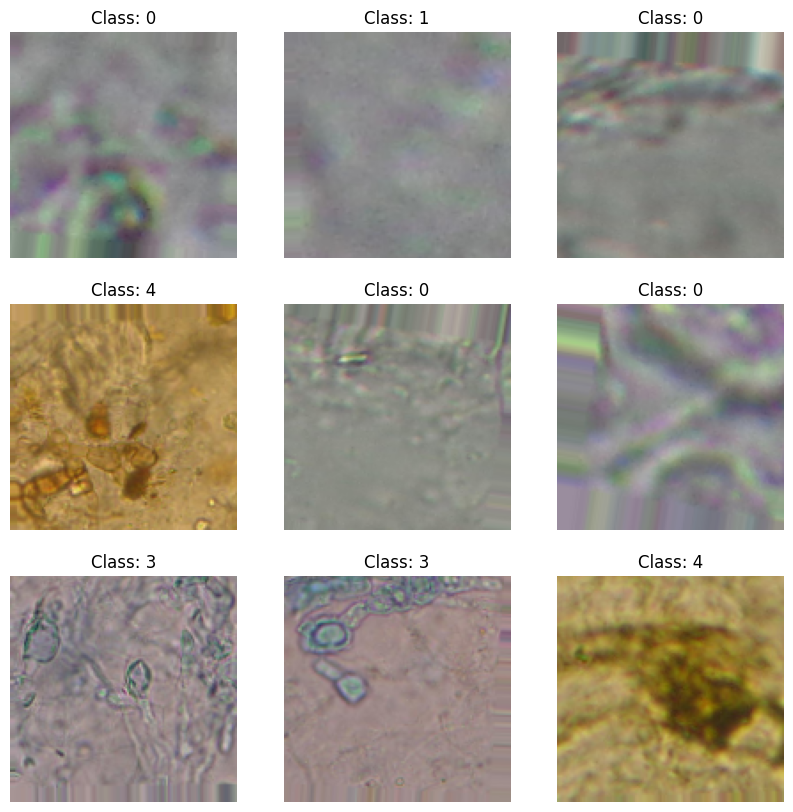

In [15]:
images, labels = next(training_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Class: " + str(int(labels[i])))
    plt.axis("off")

plt.show()

In [16]:
print("Processing Summary:")
print("Training images:", training_generator.samples)
print("Test images:", test_generator.samples)
print("Classes:", training_generator.class_indices)
print("Image size:", img_height, "x", img_width)
print("Batch size:", batch_size)

Processing Summary:
Training images: 7294
Test images: 1824
Classes: {'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}
Image size: 128 x 128
Batch size: 32


# First Model

A **Convolutional Neural Network (CNN)** was selected for this classification task,
based on Korkmaz et al. (2026) [1], which demonstrates that CNN architectures achieve
the best results for fungi image classification, reaching up to 93% accuracy with a
single model. Following the same principle, convolutional layers for feature
extraction followed by dense layers for classification, a custom CNN was implemented from scratch using TensorFlow/Keras.

The metrics used for evaluation are also based on [1]: **Precision**, **Recall**,
and **F1-Score**, since they provide a more detailed view of performance per class,
which is especially important given the class imbalance in the DeFungi dataset.
Accuracy is used only to monitor training and detect overfitting.

[1] Korkmaz et al. (2026). Explainable deep learning ensemble framework for accurate
classification of wild poisonous mushroom species. BMC Biotechnology, 26:11.
https://doi.org/10.1186/s12896-025-01092-z

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [18]:
num_classes = len(training_generator.class_indices)
class_names = list(training_generator.class_indices.keys())
print("Number of classes:", num_classes)

Number of classes: 5


In [19]:
model = Sequential([

    # Bloque 1
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    # Bloque 2
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Bloque 3
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    MaxPooling2D(2, 2),

    # Capas densas
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,117 (1.09 MB)

 Trainable params: 286,117 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    training_generator,
    epochs=10,
    validation_data=test_generator,
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 170s 738ms/step - accuracy: 0.5207 - loss: 1.2276 - val_accuracy: 0.6294 - val_loss: 0.9623
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 168s 736ms/step - accuracy: 0.5805 - loss: 1.0623 - val_accuracy: 0.6031 - val_loss: 0.9924
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 169s 740ms/step - accuracy: 0.5931 - loss: 1.0189 - val_accuracy: 0.6299 - val_loss: 0.9843
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 168s 734ms/step - accuracy: 0.6097 - loss: 1.0019 - val_accuracy: 0.6096 - val_loss: 0.9870
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 166s 726ms/step - accuracy: 0.6108 - loss: 0.9842 - val_accuracy: 0.6272 - val_loss: 0.9439
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 169s 739ms/step - accuracy: 0.6124 - loss: 0.9898 - val_accuracy: 0.6250 - val_loss: 0.9484
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 166s 727ms/step - accuracy: 0.6157 - loss: 0.9673 - val_accuracy: 0.6245 - val_loss: 0.9357
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 172s 753ms/step - accuracy: 0.6157 -

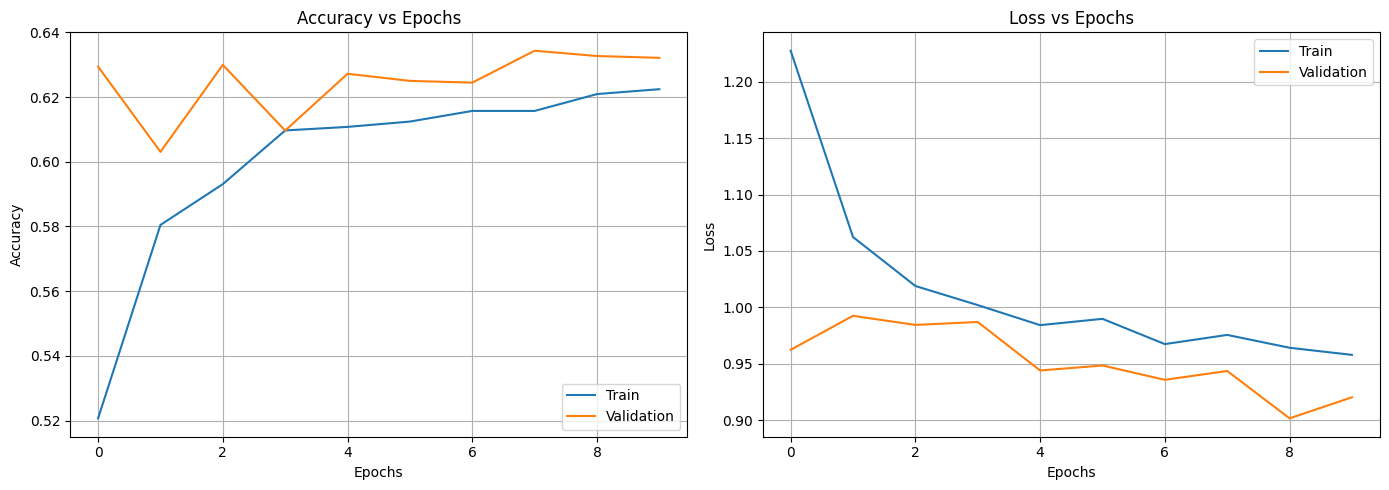

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [27]:
test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}  ({test_accuracy * 100:.2f}%)")

57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.6321 - loss: 0.9201

Test Loss:     0.9201
Test Accuracy: 0.6321  (63.21%)


In [28]:
test_generator.reset()
steps = int(np.ceil(test_generator.samples / batch_size))
predictions = model.predict(test_generator, steps=steps)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step


In [34]:
print("Metricas de evaluacion")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

Metricas de evaluacion
              precision    recall  f1-score   support

          H1       0.48      0.74      0.58       881
          H2       0.25      0.05      0.09       467
          H3       0.14      0.04      0.07       164
          H5       0.09      0.07      0.08       164
          H6       0.06      0.08      0.07       148

    accuracy                           0.39      1824
   macro avg       0.21      0.20      0.18      1824
weighted avg       0.32      0.39      0.32      1824



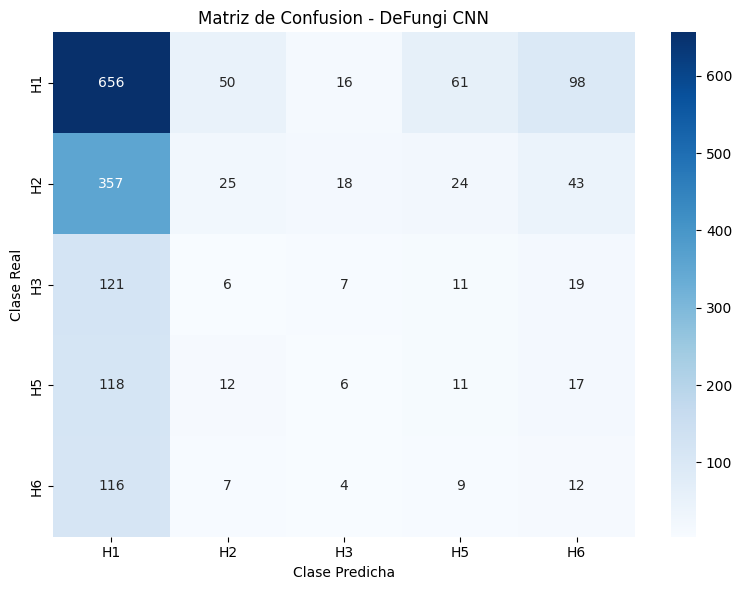

In [35]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusion - DeFungi CNN')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

## Conclusions

- The model does not show signs of overfitting since train and validation accuracy
  remained close throughout all 10 epochs (~62% vs ~63%)
- The real test accuracy is **39%** (718/1,824 correct predictions), as confirmed by
  the classification report and confusion matrix. The `model.evaluate` result of 63.21%
  was found to not reflect the actual performance over the full dataset, so the
  classification report was used as the primary evaluation source
- The model developed a strong bias toward class H1, predicting it for the majority
  of samples regardless of their true class. This is a direct consequence of the class
  imbalance in the dataset, where H1 has 4,404 training images compared to only 739
  for H6
- The classes with the least training data (H3, H5, H6) have F1-scores below 0.10,
  confirming that the model was unable to learn these minority classes effectively
- H1 achieved the best performance with a recall of 0.74 and an F1-score of 0.58,
  since it has by far the most training examples